### Library imports

In [1]:
# Importing required libraries
import os
import glob
import torch
import numpy as np
import pandas as pd
from PIL import Image
from torch.optim import Adam
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from torchvision import transforms
from torch.utils.data import DataLoader
from matplotlib.patches import Rectangle
from torchvision.models import detection
from torch.utils.data import Dataset, random_split

### Basic definitions

In [2]:
# # Define directory names
# root_dir = "PennFudanPed"
# annots_dir = "Annotation"
# masks_dir = "PedMasks"
# images_dir = "PNGImages"

# # Define directory paths
# images_path = os.path.join(root_dir, images_dir)
# annots_path = os.path.join(root_dir, annots_dir)
# masks_path = os.path.join(root_dir, masks_dir)

# print("Images path:", images_path)
# print("Annotations path:", annots_path)
# print("Masks path:", masks_path)

# Define directory names
root_dir = "Stanford-Dogs"
annots_dir = "Annotation"
images_dir = "Images"

# Define directory paths
images_path = os.path.join(root_dir, images_dir)
annots_path = os.path.join(root_dir, annots_dir)

print("Images path:", images_path)
print("Annotations path:", annots_path)

Images path: Stanford-Dogs\Images
Annotations path: Stanford-Dogs\Annotation


### Dataset and preprocessing

In [3]:
# Create pytorch compatible dataset for easy accessing of data
class PennFudanPedDataset(Dataset):
    def __init__(self, images_dirpath, annots_dirpath, transforms=None):
        # Create instance variables
        self.images_dirpath = images_dirpath
        self.annots_dirpath = annots_dirpath
        self.transforms = transforms
        # Retrieve images that ends with ".jpg"
        self.images = glob.glob(os.path.join(images_dirpath, "*/*.jpg"))
    

    def __len__(self):
        # return the length of the dataset.
        return len(self.images)
    
    def __getitem__(self, index):
        # Retrieve the filename from the path 
        location, image_name = os.path.split(self.images[index])
        location, parent_folder = os.path.split(location)
        # Open and read image into PIL format
        image = Image.open(self.images[index]).convert("RGB")
        # Apply image transformations (if any)
        if self.transforms:
            image = self.transforms(image)
        # Get annotation file name
        annot_path = os.path.join(self.annots_dirpath, parent_folder, image_name.replace(".jpg", ""))
        # Read the file and extract bounding box coordinates
        tree = ET.parse(annot_path)
        box_objects = tree.findall("object/bndbox")
        # List to store bounding boxes (structure: [Xmin, Ymin, Xmax, Ymax])
        bboxes = [list(map(int, (box.find("xmin").text, box.find("ymin").text, box.find("xmax").text, box.find("ymax").text))) for box in box_objects]
        labels = [1] * len(bboxes)
        target = {"boxes": torch.as_tensor(bboxes, dtype=torch.float32), "labels": torch.as_tensor(labels, dtype=torch.int64)}
        # Return images and bounding boxes
        return image, target

In [4]:
image_transforms = transforms.Compose([
    transforms.ToTensor()
])

data = PennFudanPedDataset(images_dirpath=images_path,
                           annots_dirpath=annots_path,
                           transforms=image_transforms)
print("Items in dataset:", len(data))

Items in dataset: 152


Text(0.5, 1.0, 'Sample image with Bounding boxes')

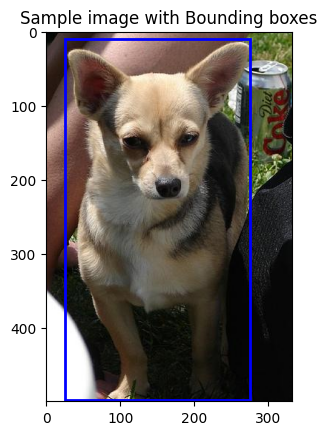

In [5]:
# Plot sample image
fig, ax = plt.subplots()
image_, target_ = data[0]
ax.imshow(image_.numpy().transpose(1, 2, 0))
for bbox in target_["boxes"]:
    width_ = bbox[2] - bbox[0]
    height_ = bbox[3] - bbox[1]
    ax.add_patch(Rectangle([bbox[0], bbox[1]], width_, height_, fill=False, lw=2, edgecolor="blue"))
ax.set_title("Sample image with Bounding boxes")

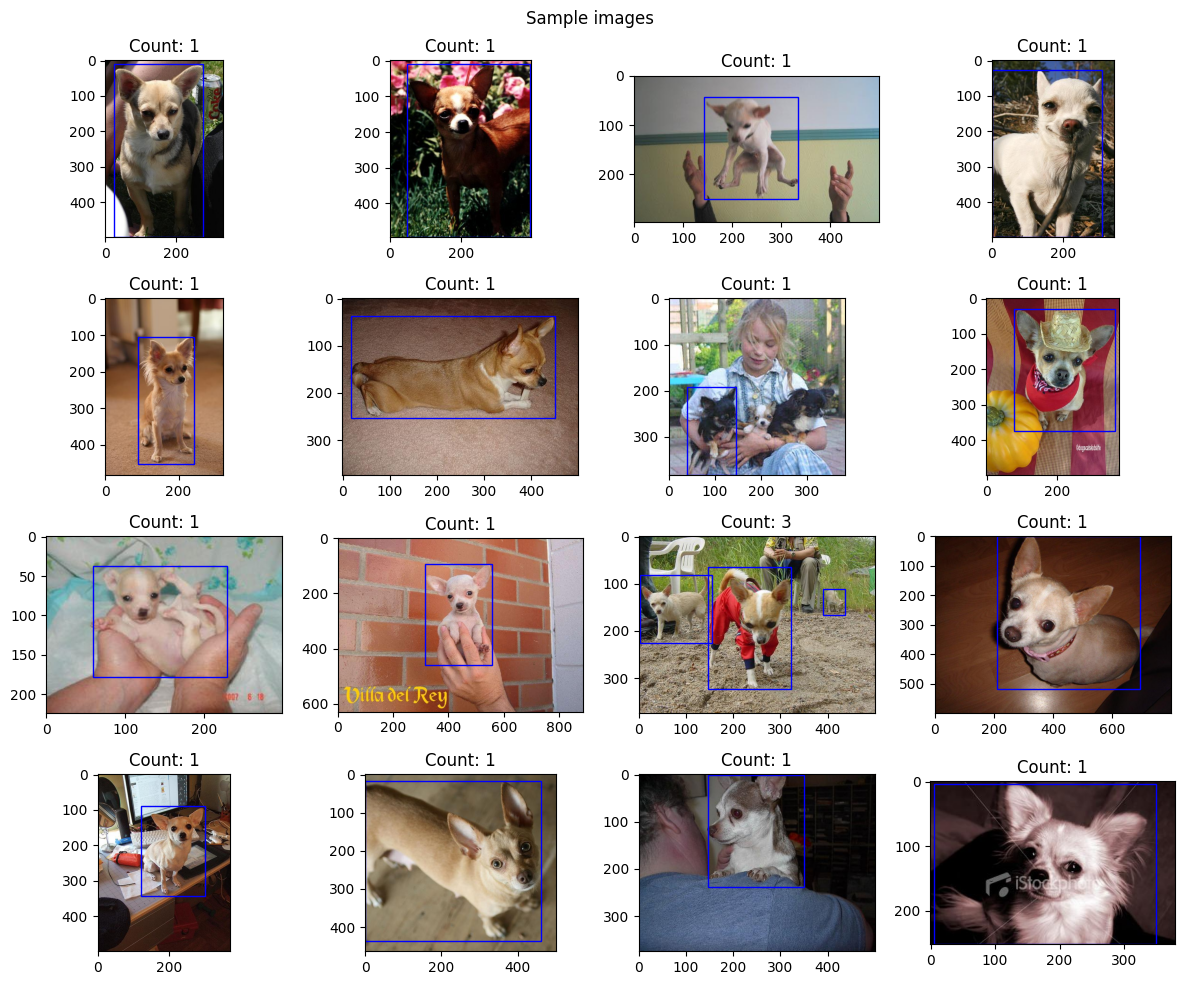

In [6]:
# Plot a grid of sample images
fig, ax = plt.subplots(ncols=4, nrows=4)
fig.set_size_inches(12, 10)
for i in range(4):
    for j in range(4):
        ax_ = ax[i, j]
        image_, target_= data[4 * i + j]
        ax_.imshow(image_.numpy().transpose(1, 2, 0))
        for bbox in target_["boxes"]:
            width_ = bbox[2] - bbox[0]
            height_ = bbox[3] - bbox[1]
            ax_.add_patch(Rectangle([bbox[0], bbox[1]], width_, height_, fill=False, lw=1, edgecolor="blue"))
        ax_.set_title(f"Count: {len(target_['boxes'])}")

fig.suptitle("Sample images")
plt.tight_layout()

In [7]:
# Perform splitting for training and validation

train_size = int(0.8 * len(data))
val_size = len(data) - train_size

train_data, val_data = random_split(data, [train_size, val_size])

print("Training data items:", len(train_data))
print("Validation data items:", len(val_data))

Training data items: 121
Validation data items: 31


In [8]:
train_loader = DataLoader(train_data, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_data, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

print("Training loader batches:", len(train_loader))
print("Validation loader batches:", len(val_loader))

Training loader batches: 31
Validation loader batches: 8


### Model Building

In [9]:
# function to retirieve  the model. 
def get_model(num_classes):
    # Using pretrained faster RCNN model with resnet-50 as backbone.
    model = detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    # Updating the head to match the number of classes from 2.
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    return model

num_classes = 2
model = get_model(num_classes)

### Model Training

In [10]:
# Leverage the GPU if available.
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu"
          )

print("Using Device:", device)

Using Device: cuda


In [11]:
# Transfer the model to available device
model.to(device)
# Define the optimizer  
optimizer = Adam(model.parameters(), lr=0.0001)

In [12]:
# Sample forward run.

images_, targets_ = next(iter(train_loader))
images_ = list(image.to(device) for image in images_)
targets_ = [{k: v.to(device) for k, v in t.items()} for t in targets_]
outputs_ = model(images_, targets_)
print(outputs_)

{'loss_classifier': tensor(0.4509, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1464, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0082, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0097, device='cuda:0', grad_fn=<DivBackward0>)}


In [13]:
# A function to train the model
def train(model, train_loader, val_loader, optimizer, n_epochs=10):
    # Store the average scores for training and validation
    scores = {"train_epoch_means": [], "val_epoch_means": []}
    # For each epoch:
    for epoch in range(1, n_epochs+1):
        # TRAINING
        # Set the model to training mode
        model.train()
        # List to store batch wise scores
        epoch_scores = []
        # For each batch:
        for batch_num, (images, targets) in enumerate(train_loader, 1):
            # Transfer images, targets to available device
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            # Feed forward through model
            loss_outputs = model(images, targets)
            # Sum up the losses
            loss_sum = sum(loss_outputs.values())
            epoch_scores.append(loss_sum.detach().cpu().numpy().item())
            # back propagation
            optimizer.zero_grad()
            loss_sum.backward()
            optimizer.step()

            if batch_num % 10 == 0:
                print(f"EPOCH {epoch} of {n_epochs} - BATCH {batch_num} of {len(train_loader)} - LOSS {loss_sum}")
        
        scores["train_epoch_means"].append(np.mean(epoch_scores))
        scores[f"epoch_{epoch}"] = epoch_scores
        # VALIDATION
        with torch.no_grad():
            total_val_loss = 0
            # For each batch in validation loader:
            for images, targets in val_loader:
                # Transfer images, targets to available device
                images = list(image.to(device) for image in images)
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                # Feed forward through model
                loss_outputs = model(images, targets)
                total_val_loss += sum(loss_outputs.values())
            
            # Compute average loss over validation dataset.
            mean_val_loss = total_val_loss / len(val_loader)
            scores["val_epoch_means"].append(mean_val_loss.detach().cpu().numpy().item())
            print(f"EPOCH {epoch} of {n_epochs} - VALIDATION - LOSS {mean_val_loss}")

    return scores

In [15]:
# Train the model for 20 epochs
scores = train(model, train_loader, val_loader, optimizer, n_epochs=10)

EPOCH 1 of 10 - BATCH 10 of 31 - LOSS 0.1729854941368103
EPOCH 1 of 10 - BATCH 20 of 31 - LOSS 0.16104629635810852
EPOCH 1 of 10 - BATCH 30 of 31 - LOSS 0.1770949363708496
EPOCH 1 of 10 - VALIDATION - LOSS 0.1621074378490448
EPOCH 2 of 10 - BATCH 10 of 31 - LOSS 0.12307663261890411
EPOCH 2 of 10 - BATCH 20 of 31 - LOSS 0.12890425324440002
EPOCH 2 of 10 - BATCH 30 of 31 - LOSS 0.10629124939441681
EPOCH 2 of 10 - VALIDATION - LOSS 0.12839879095554352
EPOCH 3 of 10 - BATCH 10 of 31 - LOSS 0.10997850447893143
EPOCH 3 of 10 - BATCH 20 of 31 - LOSS 0.08126997947692871
EPOCH 3 of 10 - BATCH 30 of 31 - LOSS 0.07382742315530777
EPOCH 3 of 10 - VALIDATION - LOSS 0.11020299792289734
EPOCH 4 of 10 - BATCH 10 of 31 - LOSS 0.1043049767613411
EPOCH 4 of 10 - BATCH 20 of 31 - LOSS 0.07739528268575668
EPOCH 4 of 10 - BATCH 30 of 31 - LOSS 0.0868024155497551
EPOCH 4 of 10 - VALIDATION - LOSS 0.10173046588897705
EPOCH 5 of 10 - BATCH 10 of 31 - LOSS 0.09910937398672104
EPOCH 5 of 10 - BATCH 20 of 31 - LO

In [16]:
# Save and store the obtained scores and trained model
torch.save(scores, "dog_scores.pkl")
torch.save(model, "dog_model.pth")

In [20]:
training_scores = torch.load("dog_scores.pkl")
list(training_scores.keys())

['train_epoch_means',
 'val_epoch_means',
 'epoch_1',
 'epoch_2',
 'epoch_3',
 'epoch_4',
 'epoch_5',
 'epoch_6',
 'epoch_7',
 'epoch_8',
 'epoch_9',
 'epoch_10']

ValueError: The number of FixedLocator locations (10), usually from a call to set_ticks, does not match the number of labels (50).

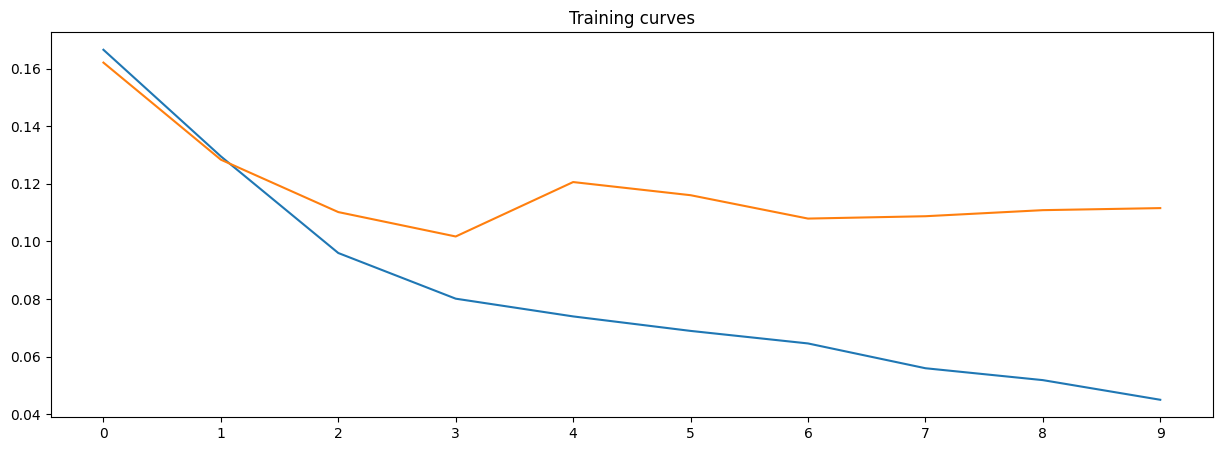

In [21]:
# Plot the graphs for training and validation scores
train_scores = training_scores.pop("train_epoch_means")
val_scores =  training_scores.pop("val_epoch_means")

plt.figure(figsize=(15, 5))
plt.plot(train_scores, label="Training")
plt.plot(val_scores, label="Validation")
plt.title("Training curves")
plt.xticks(range(10), range(1, 51))
plt.legend()

<Axes: title={'center': 'Epoch wise training curves'}>

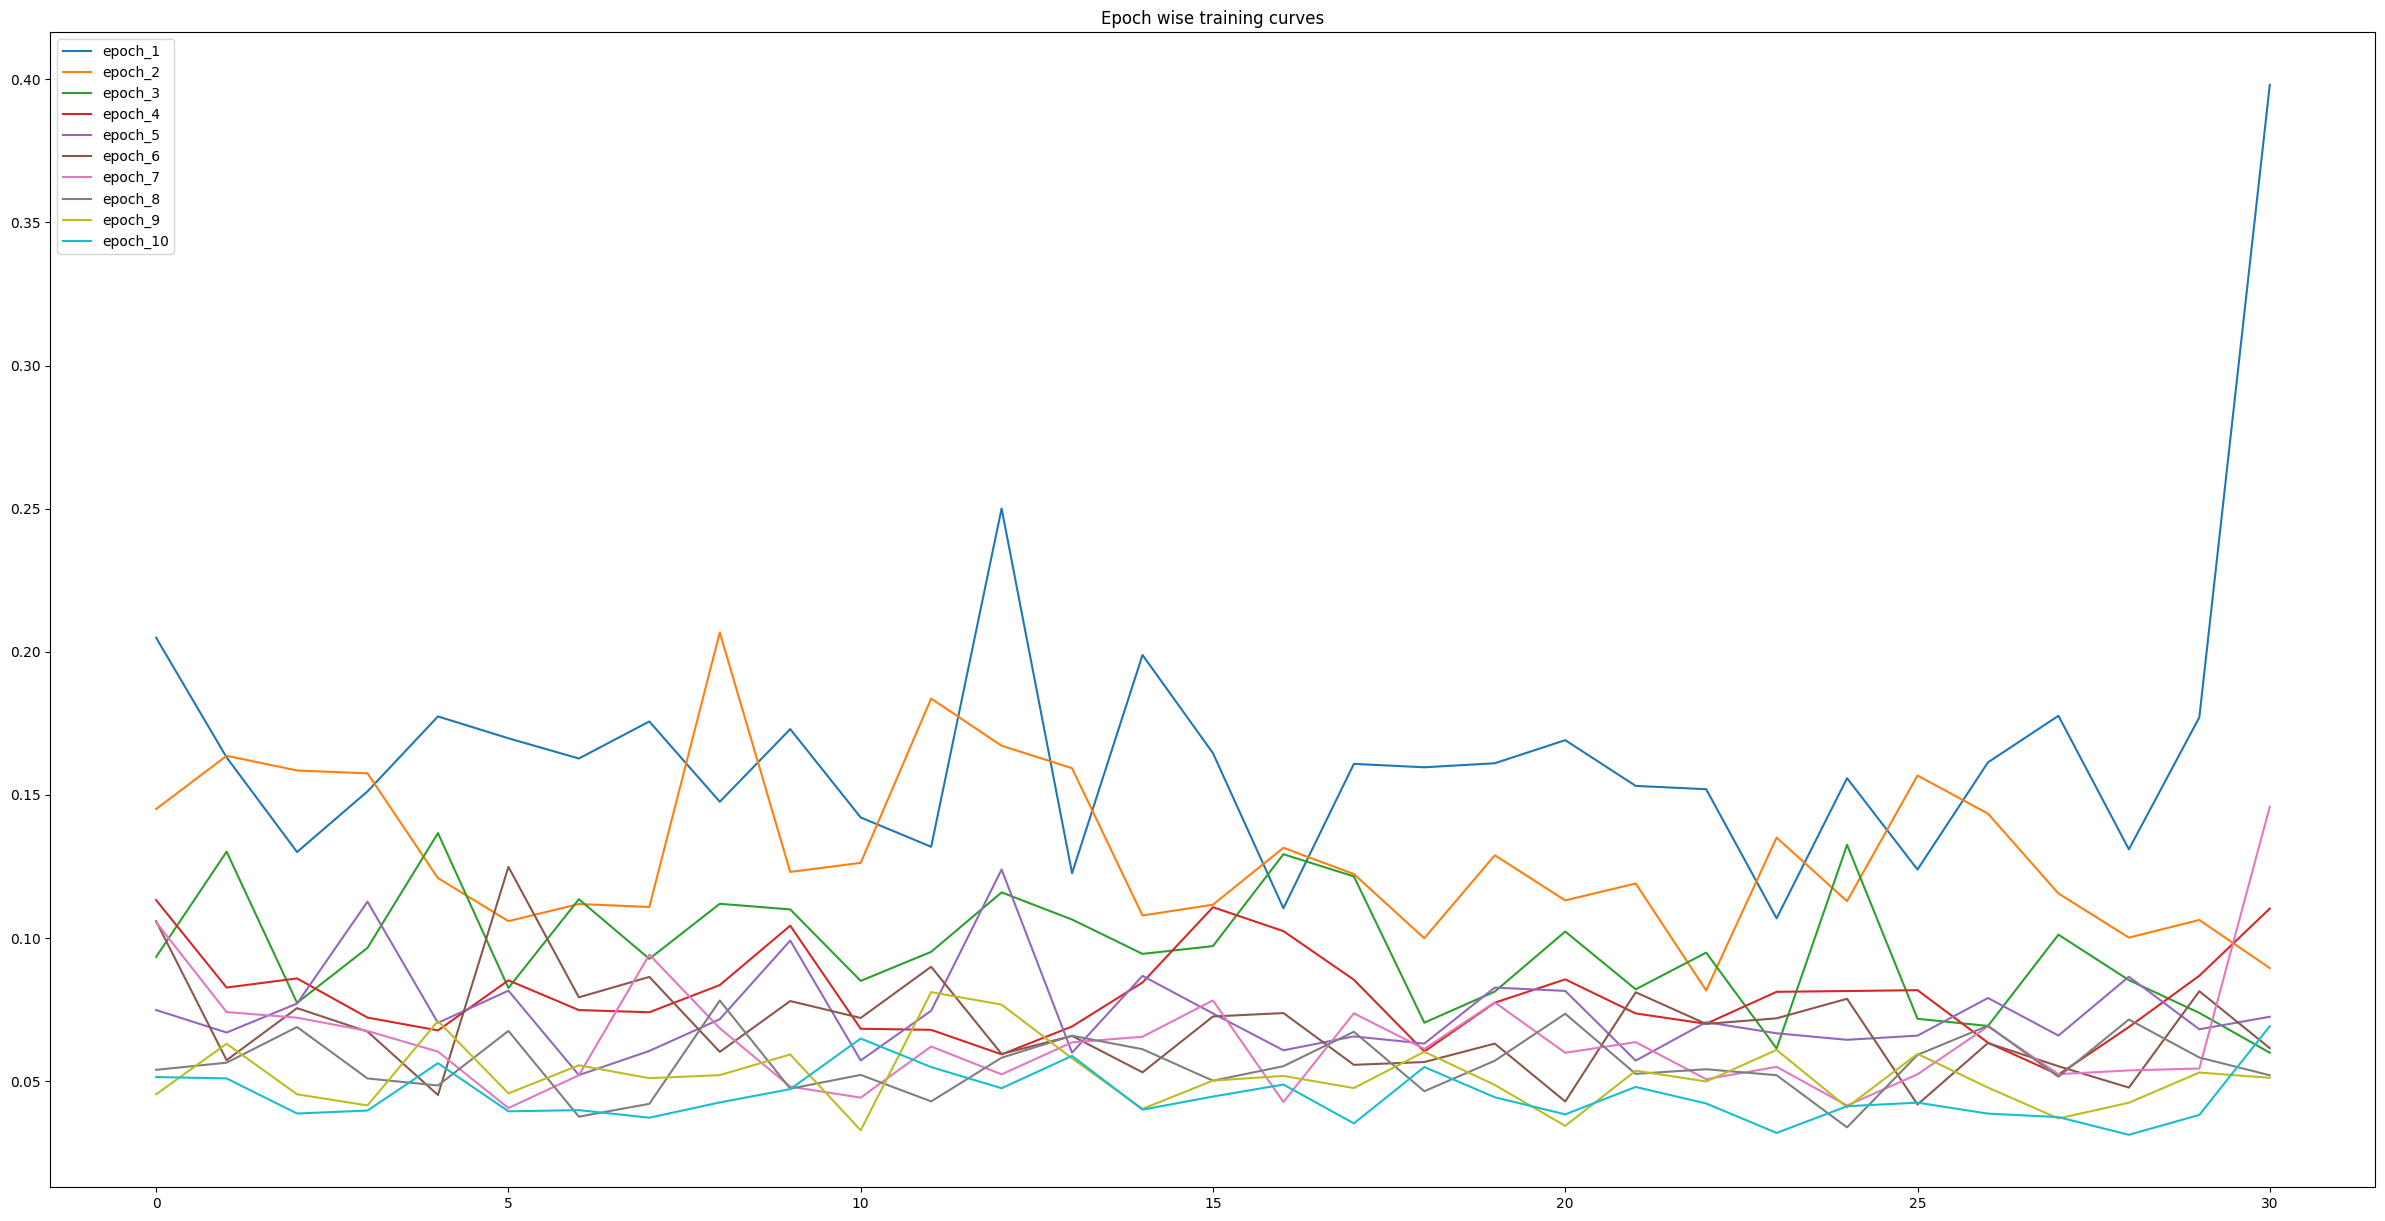

In [22]:
# Build data frame and plot epoch wise training scores
epoch_df = pd.DataFrame(training_scores)
epoch_df.plot(figsize=(30, 15), title="Epoch wise training curves")

### Visualize the results

In [23]:
# Take the first batch from validation loader
images, targets = next(iter(val_loader))

In [24]:
# Transfer the images and targets to available device
images = list(image.to(device) for image in images)
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

In [25]:
# Set the model to evaluation mode
model.eval()
prediction_output = []
with torch.no_grad():
    # List to store predictions
    predictions = []
    # Feed forward through network
    outputs = model(images)
    # For each target and output:
    for target, output in zip(targets, outputs):
        # Collect the boxes, labels, and scores
        pred_boxes = output["boxes"].cpu().numpy()
        pred_labels = output["labels"].cpu().numpy()
        pred_scores = output["scores"].cpu().numpy()
        # Set the score threshold
        score_thr = 0.5
        # Only pick the scores that are above the threshold
        valid_indices = pred_scores > score_thr
        boxes = pred_boxes[valid_indices]
        labels = pred_labels[valid_indices]
        scores = pred_scores[valid_indices]
        
        # Store a dictionary with filtered boxes, labels, and scores
        temp_pred_dict = {
            "boxes": boxes, "labels": labels, "scores": scores
        }
        prediction_output.append(temp_pred_dict)

In [26]:
# Sample prediction output structure
prediction_output[0]

{'boxes': array([[124.12739,  88.65643, 296.029  , 348.13098]], dtype=float32),
 'labels': array([1], dtype=int64),
 'scores': array([0.9963069], dtype=float32)}

Text(0.5, 0.98, 'Validation images; Red: Prediction; Blue: True')

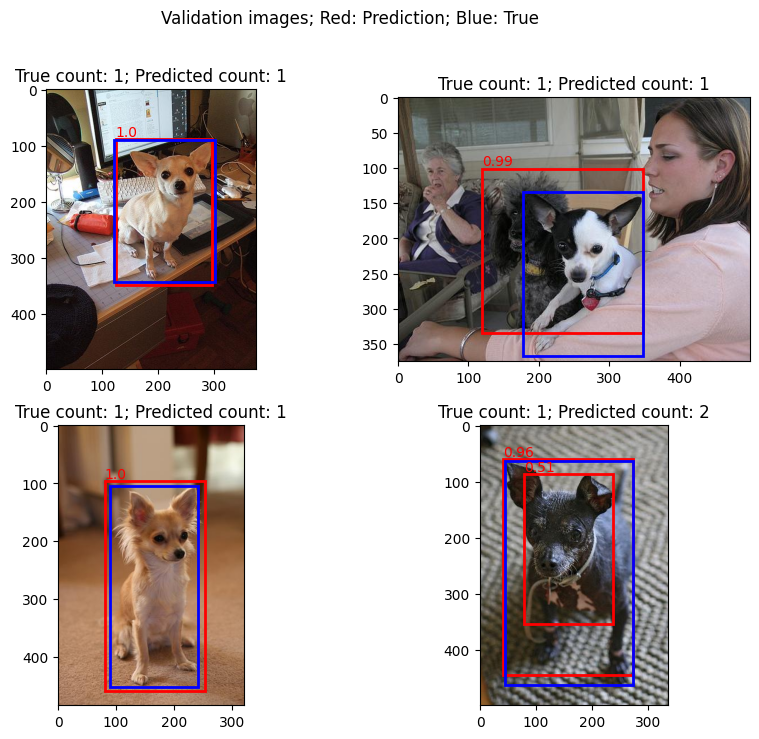

In [27]:
# Plot the predictions and true values together for 1 batch
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(10, 8)
for i in range(2):
    for j in range(2):
        idx = 2 * i + j
        ax_ = ax[i, j]
        # Plot image
        ax_.imshow(images[idx].cpu().numpy().transpose(1, 2, 0))
        # Plot predicted boxes and scors
        for bbox, score in zip(prediction_output[idx]["boxes"], prediction_output[idx]["scores"]):
            width_ = bbox[2] - bbox[0]
            height_ = bbox[3] - bbox[1]
            ax_.add_patch(Rectangle([bbox[0], bbox[1]], width_, height_, fill=False, lw=2, edgecolor="red"))
            predicted_count = sum(prediction_output[idx]['labels'])
            # Add text to show the score
            ax_.text(bbox[0], bbox[1]-5, round(score, 2), color="red")
        # Similarly, add the ground truth boxes.
        for bbox in targets[idx]["boxes"].cpu():
            width_ = bbox[2] - bbox[0]
            height_ = bbox[3] - bbox[1]
            ax_.add_patch(Rectangle([bbox[0], bbox[1]], width_, height_, fill=False, lw=2, edgecolor="blue"))
            true_count = sum(targets[idx]['labels'])
        ax_.set_title(f"True count: {true_count}; Predicted count: {predicted_count}")
        
fig.suptitle("Validation images; Red: Prediction; Blue: True")

### Testing

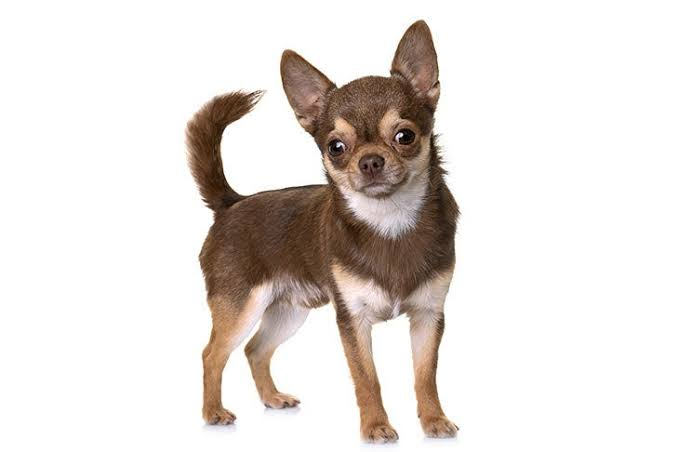

In [28]:
# Path to testing image
test_image_path = "test_chihuahua.jpg"
# Open the image and convert it to 3-channel RGB
test_image = Image.open(test_image_path).convert("RGB")
# Display the image
test_image

In [29]:
# Apply transformations to test image (to_tensor)
test_image_tensor = image_transforms(test_image)
# Re-structurize the image to add one more dimension
test_image_final = torch.unsqueeze(test_image_tensor, dim=0)
# Transfer the image to device
test_image_final = test_image_final.to(device)

In [30]:
# Check the shape of the final version of image
test_image_final.shape

torch.Size([1, 3, 452, 678])

In [31]:
# Feed forward through the model
test_output = model(test_image_final)[0]

Text(0.5, 1.0, 'Predicted count: 1')

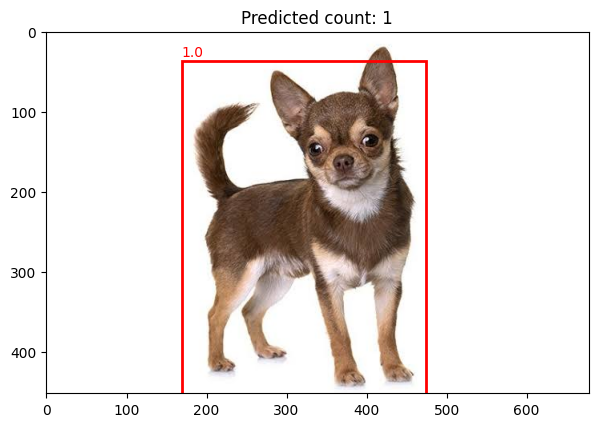

In [32]:
# Create a plot
fig, ax = plt.subplots()
fig.set_size_inches(7, 5)

# Plot the image
ax.imshow(test_image_final.squeeze().cpu().numpy().transpose(1, 2, 0))
# For each predicted box and score:
for bbox, score in zip(test_output["boxes"].detach().cpu().numpy(), test_output["scores"].detach().cpu().numpy()):
    width_ = bbox[2] - bbox[0]
    height_ = bbox[3] - bbox[1]
    # Add rectangle patches for each box
    ax.add_patch(Rectangle([bbox[0], bbox[1]], width_, height_, fill=False, lw=2, edgecolor="red"))
    # Compute the number of boxes (predictions)
    predicted_count = sum(test_output['labels'])
    # Add the text at the left top corner of the box
    ax.text(bbox[0], bbox[1]-5, round(score, 2), color="red")

ax.set_title(f"Predicted count: {predicted_count}")

### Test Custom Images

In [33]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from matplotlib.patches import Rectangle

In [37]:
image_transforms = transforms.Compose([
    transforms.ToTensor()
])

device = "cpu"

model = torch.load("dog_model.pth", map_location=torch.device('cpu'))
_ = model.eval()

In [38]:
def process_test_image(test_image_path):
    # Open the image and convert it to 3-channel RGB
    test_image = Image.open(test_image_path).convert("RGB")
    
    # Apply transformations to test image (to_tensor)
    test_image_tensor = image_transforms(test_image)
    # Re-structurize the image to add one more dimension
    test_image_final = torch.unsqueeze(test_image_tensor, dim=0)
    # Transfer the image to device
    test_image_final = test_image_final.to(device)

    # Feed forward through the model
    test_output = model(test_image_final)[0]

    # Create a plot
    fig, ax = plt.subplots()
    fig.set_size_inches(7, 5)

    # Plot the image
    ax.imshow(test_image_final.squeeze().cpu().numpy().transpose(1, 2, 0))
    # For each predicted box and score:
    for bbox, score in zip(test_output["boxes"].detach().cpu().numpy(), test_output["scores"].detach().cpu().numpy()):
        width_ = bbox[2] - bbox[0]
        height_ = bbox[3] - bbox[1]
        # Add rectangle patches for each box
        ax.add_patch(Rectangle([bbox[0], bbox[1]], width_, height_, fill=False, lw=2, edgecolor="red"))
        # Compute the number of boxes (predictions)
        predicted_count = sum(test_output['labels'])
        # Add the text at the left top corner of the box
        ax.text(bbox[0], bbox[1]-5, round(score, 2), color="red")

    ax.set_title(f"Predicted count: {predicted_count}")
    plt.show()

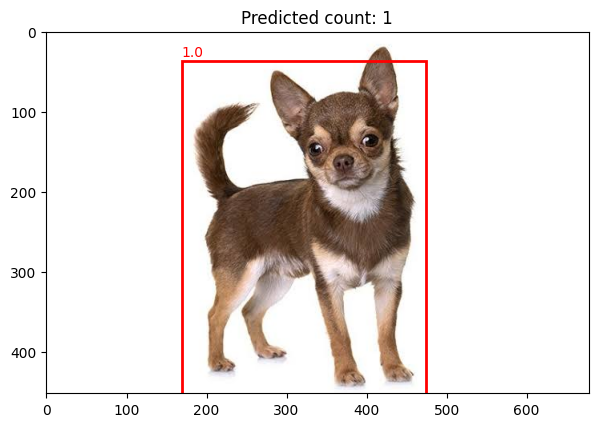

In [39]:
process_test_image("test_chihuahua.jpg")